# Demo: Using Pretrained EpiAgent for Zero-Shot Cell Embeddings on Kanemaru2023 Dataset

This notebook demonstrates the use of the pretrained EpiAgent model, which has been trained on the large-scale Human-scATAC-Corpus with approximately 5 million cells and 35 billion tokens. It illustrates a zero-shot inference workflow to extract cell embeddings from the downsampled Kanemaru2023 dataset (Kanemaru2023_downsampled_10000_cells.h5ad).

Required files:

	•	pretrained_EpiAgent.pth: The pretrained EpiAgent model.
	•	Kanemaru2023_downsampled_10000_cells.h5ad: The downsampled Kanemaru2023 dataset.

These files are available at the following link: https://drive.google.com/drive/folders/1WlNykSCNtZGsUp2oG0dw3cDdVKYDR-iX?usp=sharing.

# Step 1: Data Processing (TFIDF and Tokenization)

To prepare the Kanemaru2023 dataset for EpiAgent, we perform the following preprocessing steps:

1.TFIDF Transformation: Convert discrete count data into continuous importance scores for accessible cCREs.
    
2.Tokenization: Generate cell_sentences to represent each cell as a sequence of accessible cCRE indices.

In [1]:
import random
import numpy as np
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

In [ ]:
import scanpy as sc
import numpy as np
from epiagent.tokenization import tokenization
from epiagent.preprocessing import global_TFIDF

# Load the dataset
input_path = '../data/sample/raw_h5ad/Kanemaru2023_downsampled_10000_cells.h5ad'
adata = sc.read_h5ad(input_path)

# Load the cCRE document frequency data
cCRE_document_frequency = np.load('../data/cCRE_document_frequency.npy')

# No permutations

In [ ]:
# Apply TFIDF transformation
adata_tfidf = global_TFIDF(adata, cCRE_document_frequency)

# Perform tokenization
tokenization(adata_tfidf)

# Step 2: Create Dataset and DataLoader

We create a PyTorch-compatible Dataset and DataLoader to handle tokenized cell_sentences from the processed AnnData object. Each cell is represented as a sequence of tokens with special tokens [CLS] and [SEP].

In [ ]:
from epiagent.dataset import CellDataset, collate_fn
from torch.utils.data import DataLoader

# Create the dataset
cell_sentences = adata_tfidf.obs['cell_sentences'].tolist()
cell_dataset = CellDataset(cell_sentences=cell_sentences)

# Create the DataLoader
batch_size = 15
dataloader = DataLoader(cell_dataset, batch_size=batch_size, shuffle=False, num_workers=4, collate_fn=collate_fn)

# Step 3: Load Pretrained EpiAgent Model

The pretrained EpiAgent model (pretrained_EpiAgent.pth) is loaded for zero-shot inference to compute cell embeddings.

In [6]:
from epiagent.model import EpiAgent
import torch

# Load the pretrained model
model_path = '../model/pretrained_EpiAgent.pth'
device = torch.device("cuda:3" if torch.cuda.is_available() else "cpu")

pretrained_model = EpiAgent(vocab_size=1355449, num_layers=18, embedding_dim=512, num_attention_heads=8, max_rank_embeddings=8192, use_flash_attn=True, pos_weight_for_RLM=torch.tensor(1.), pos_weight_for_CCA=torch.tensor(1.))
pretrained_model.load_state_dict(torch.load(model_path, map_location=device))

/home/naimer/miniforge3/envs/EpiAgentBench/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<All keys matched successfully>

# Step 4: Extract Cell Embeddings


The infer_cell_embeddings function is used to compute cell embeddings using the pretrained EpiAgent model.

In [5]:
from epiagent.inference import infer_cell_embeddings

# Extract cell embeddings
cell_embeddings = infer_cell_embeddings(pretrained_model, device, dataloader)

# Step 5: UMAP Visualization

Perform UMAP visualization to project the embeddings into a 2D space.

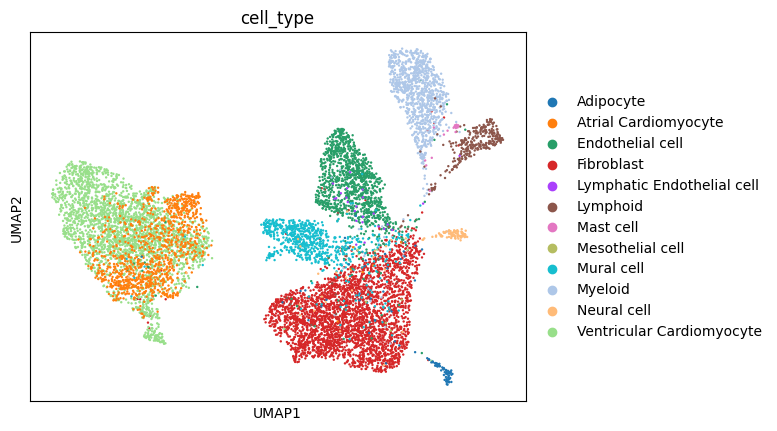

In [6]:
import scanpy as sc

# Assign embeddings to the AnnData object
adata_tfidf.obsm['cell_embeddings_zero_shot'] = cell_embeddings

# UMAP visualization
sc.pp.neighbors(adata_tfidf, use_rep='cell_embeddings_zero_shot')
sc.tl.umap(adata_tfidf)

# Plot UMAP with original cell types
sc.pl.umap(adata_tfidf, color='cell_type')

# # Save the processed AnnData
# output_path = '../data/sample/processed_h5ad/Kanemaru2023_downsampled_10000_cells_EpiAgent_zero_shot_outputs.h5ad'
# adata_tfidf.write(output_path)
# print(f"Processed AnnData saved at {output_path}")

In [7]:
pretrained_model.criterion_CCA.pos_weight

tensor(1., device='cuda:3')

In [9]:
print(f"Number of cell types: {len(adata_tfidf.obs['cell_type'].unique())}")

Number of cell types: 12


/tmp/ipykernel_3611828/3668770515.py:4: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata_tfidf, resolution=0.45, key_added='leiden', random_state=42)


Number of Leiden clusters: 12


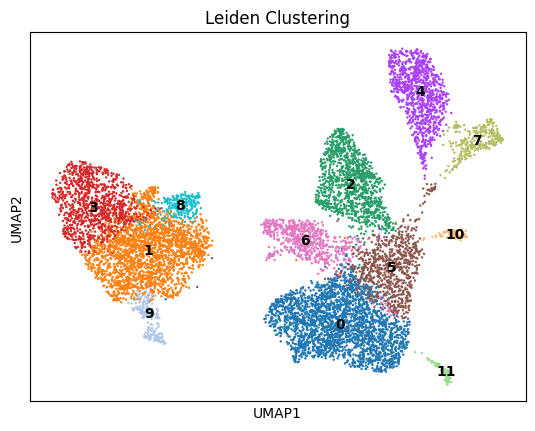

In [10]:
# Perform leiden clustering
# Note: neighbors are already computed in cell 16 using the embeddings
# We'll use a default resolution of 0.5, which can be adjusted based on desired granularity
sc.tl.leiden(adata_tfidf, resolution=0.45, key_added='leiden', random_state=42)

# Print the number of clusters found
n_clusters = len(adata_tfidf.obs['leiden'].unique())
print(f"Number of Leiden clusters: {n_clusters}")

# Visualize the Leiden clusters on UMAP
sc.pl.umap(adata_tfidf, color='leiden', legend_loc='on data', title='Leiden Clustering')

In [12]:
# Calculate NMI and ARI scores
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

# Get the true labels (cell types) and predicted labels (Leiden clusters)
true_labels = adata_tfidf.obs['cell_type'].values
predicted_labels = adata_tfidf.obs['leiden'].values

# Calculate ARI (Adjusted Rand Index)
ari_score = adjusted_rand_score(true_labels, predicted_labels)

# Calculate NMI (Normalized Mutual Information)
nmi_score = normalized_mutual_info_score(true_labels, predicted_labels)

# Print the results
print(f"Adjusted Rand Index (ARI): {ari_score:.4f}")
print(f"Normalized Mutual Information (NMI): {nmi_score:.4f}")
print(f"\nNumber of true cell types: {len(adata_tfidf.obs['cell_type'].unique())}")
print(f"Number of predicted clusters: {len(adata_tfidf.obs['leiden'].unique())}")

Adjusted Rand Index (ARI): 0.6247
Normalized Mutual Information (NMI): 0.7333

Number of true cell types: 12
Number of predicted clusters: 12


# Permute labels

In [3]:
import scanpy as sc
import numpy as np
from epiagent.tokenization import tokenization
from epiagent.preprocessing import global_TFIDF_with_shuffling

# Load the dataset
# input_path = '../data/sample/raw_h5ad/Kanemaru2023_downsampled_10000_cells.h5ad'
# Note: copy() creates a copy of the AnnData structure. The global_TFIDF_with_shuffling 
# function also creates its own internal copy, so this ensures adata_perm is separate from adata.
# adata_perm = adata.copy()

# Load the cCRE document frequency data
# cCRE_document_frequency = np.load('../data/cCRE_document_frequency.npy')

# Apply TFIDF transformation
adata_tfidf_perm = global_TFIDF_with_shuffling(adata, cCRE_document_frequency)

# Perform tokenization
tokenization(adata_tfidf_perm)

Tokenization complete: 'cell_sentences' column added to adata.obs.


In [4]:
from epiagent.dataset import CellDataset, collate_fn
from torch.utils.data import DataLoader

# Create the dataset
cell_sentences_perm = adata_tfidf_perm.obs['cell_sentences'].tolist()
cell_dataset_perm = CellDataset(cell_sentences=cell_sentences_perm)

# Create the DataLoader
batch_size = 15
dataloader_perm = DataLoader(cell_dataset_perm, batch_size=batch_size, shuffle=False, num_workers=4, collate_fn=collate_fn)

In [7]:
from epiagent.inference import infer_cell_embeddings

# Extract cell embeddings
cell_embeddings_perm = infer_cell_embeddings(pretrained_model, device, dataloader_perm)

In [ ]:
import scanpy as sc

# Assign embeddings to the AnnData object
adata_tfidf_perm.obsm['cell_embeddings_zero_shot'] = cell_embeddings_perm

# UMAP visualization
sc.pp.neighbors(adata_tfidf_perm, use_rep='cell_embeddings_zero_shot')
sc.tl.umap(adata_tfidf_perm)

# Plot UMAP with original cell types
sc.pl.umap(adata_tfidf_perm, color='cell_type')

Number of Leiden clusters: 12


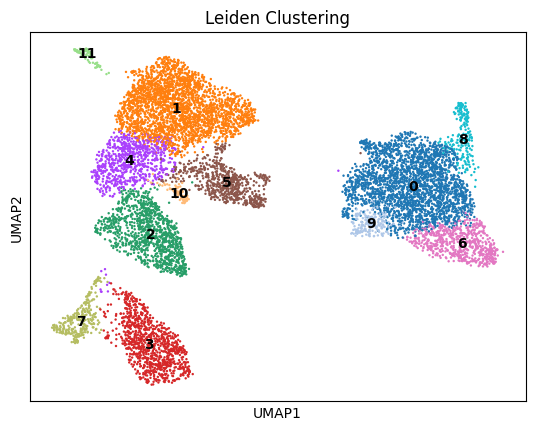

Adjusted Rand Index (ARI): 0.6321
Normalized Mutual Information (NMI): 0.7373

Number of true cell types: 12
Number of predicted clusters: 12


In [17]:
# Assign embeddings to adata_perm and compute neighbors for Leiden clustering
adata_tfidf_perm.obsm['cell_embeddings_zero_shot'] = cell_embeddings_perm

# Compute neighbors graph (required for Leiden clustering)
sc.pp.neighbors(adata_tfidf_perm, use_rep='cell_embeddings_zero_shot')

# Compute UMAP for visualization
sc.tl.umap(adata_tfidf_perm)

# Perform Leiden clustering
sc.tl.leiden(adata_tfidf_perm, resolution=0.5, key_added='leiden', random_state=42)

# Print the number of clusters found
n_clusters = len(adata_tfidf_perm.obs['leiden'].unique())
print(f"Number of Leiden clusters: {n_clusters}")

# Visualize the Leiden clusters on UMAP
sc.pl.umap(adata_tfidf_perm, color='leiden', legend_loc='on data', title='Leiden Clustering')

# Calculate NMI and ARI scores
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

# Get the true labels (cell types) and predicted labels (Leiden clusters)
true_labels = adata_tfidf_perm.obs['cell_type'].values
predicted_labels = adata_tfidf_perm.obs['leiden'].values

# Calculate ARI (Adjusted Rand Index)
ari_score = adjusted_rand_score(true_labels, predicted_labels)

# Calculate NMI (Normalized Mutual Information)
nmi_score = normalized_mutual_info_score(true_labels, predicted_labels)

# Print the results
print(f"Adjusted Rand Index (ARI): {ari_score:.4f}")
print(f"Normalized Mutual Information (NMI): {nmi_score:.4f}")
print(f"\nNumber of true cell types: {len(adata_tfidf_perm.obs['cell_type'].unique())}")
print(f"Number of predicted clusters: {len(adata_tfidf_perm.obs['leiden'].unique())}")

# Completely permuted labels

In [3]:
import scanpy as sc
import numpy as np
from epiagent.tokenization import tokenization
from epiagent.preprocessing import global_TFIDF_with_complete_shuffling

# Load the dataset
# input_path = '../data/sample/raw_h5ad/Kanemaru2023_downsampled_10000_cells.h5ad'
# Note: copy() creates a copy of the AnnData structure. The global_TFIDF_with_shuffling 
# function also creates its own internal copy, so this ensures adata_perm is separate from adata.
# adata_perm = adata.copy()

# Load the cCRE document frequency data
# cCRE_document_frequency = np.load('../data/cCRE_document_frequency.npy')

# Apply TFIDF transformation
adata_tfidf_perm_complete = global_TFIDF_with_complete_shuffling(adata, cCRE_document_frequency)

# Perform tokenization
tokenization(adata_tfidf_perm_complete)

Shuffling rows: 100%|██████████| 10001/10001 [03:40<00:00, 45.43it/s]


Tokenization complete: 'cell_sentences' column added to adata.obs.


In [4]:
from epiagent.dataset import CellDataset, collate_fn
from torch.utils.data import DataLoader

# Create the dataset
cell_sentences_perm_complete = adata_tfidf_perm_complete.obs['cell_sentences'].tolist()
cell_dataset_perm_complete = CellDataset(cell_sentences=cell_sentences_perm_complete)

# Create the DataLoader
batch_size = 15
dataloader_perm_complete = DataLoader(cell_dataset_perm_complete, batch_size=batch_size, shuffle=False, num_workers=4, collate_fn=collate_fn)

In [7]:
from epiagent.inference import infer_cell_embeddings

# Extract cell embeddings
cell_embeddings_perm_complete = infer_cell_embeddings(pretrained_model, device, dataloader_perm_complete)

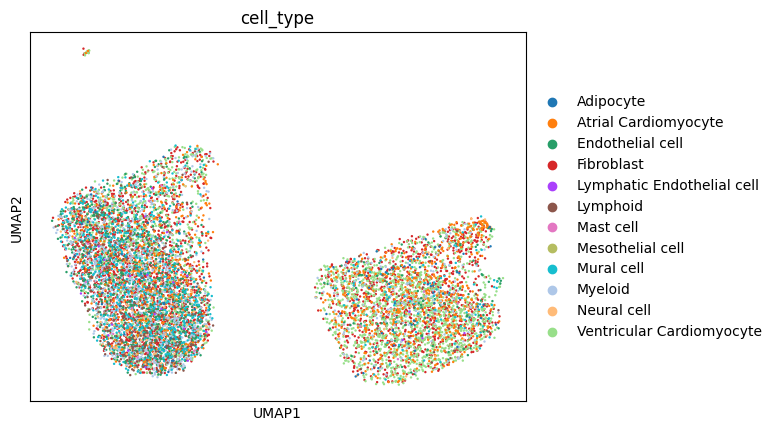

In [16]:
import scanpy as sc

# Assign embeddings to the AnnData object
adata_tfidf_perm_complete.obsm['cell_embeddings_zero_shot'] = cell_embeddings_perm_complete

# UMAP visualization
sc.pp.neighbors(adata_tfidf_perm_complete, use_rep='cell_embeddings_zero_shot')
sc.tl.umap(adata_tfidf_perm_complete)

# Plot UMAP with original cell types
sc.pl.umap(adata_tfidf_perm_complete, color='cell_type')

# # Save the processed AnnData
# output_path = '../data/sample/processed_h5ad/Kanemaru2023_downsampled_10000_cells_EpiAgent_zero_shot_outputs.h5ad'
# adata_tfidf.write(output_path)
# print(f"Processed AnnData saved at {output_path}")

Number of Leiden clusters: 12


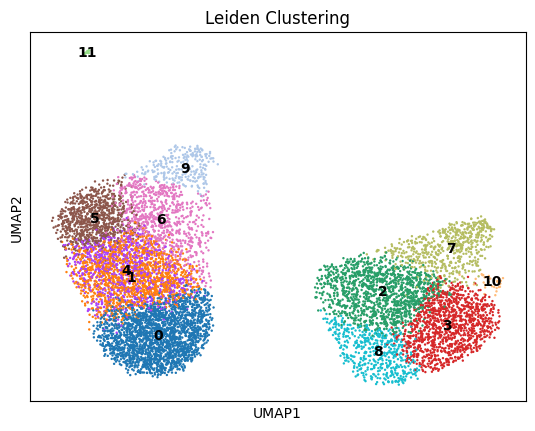

Adjusted Rand Index (ARI): 0.0149
Normalized Mutual Information (NMI): 0.0510

Number of true cell types: 12
Number of predicted clusters: 12


In [13]:
# Assign embeddings to adata_perm and compute neighbors for Leiden clustering
adata_tfidf_perm_complete.obsm['cell_embeddings_zero_shot'] = cell_embeddings_perm_complete

# Compute neighbors graph (required for Leiden clustering)
sc.pp.neighbors(adata_tfidf_perm_complete, use_rep='cell_embeddings_zero_shot')

# Compute UMAP for visualization
sc.tl.umap(adata_tfidf_perm_complete)

# Perform Leiden clustering
sc.tl.leiden(adata_tfidf_perm_complete, resolution=1.2, key_added='leiden', random_state=42)

# Print the number of clusters found
n_clusters = len(adata_tfidf_perm_complete.obs['leiden'].unique())
print(f"Number of Leiden clusters: {n_clusters}")

# Visualize the Leiden clusters on UMAP
sc.pl.umap(adata_tfidf_perm_complete, color='leiden', legend_loc='on data', title='Leiden Clustering')

# Calculate NMI and ARI scores
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

# Get the true labels (cell types) and predicted labels (Leiden clusters)
true_labels = adata_tfidf_perm_complete.obs['cell_type'].values
predicted_labels = adata_tfidf_perm_complete.obs['leiden'].values

# Calculate ARI (Adjusted Rand Index)
ari_score = adjusted_rand_score(true_labels, predicted_labels)

# Calculate NMI (Normalized Mutual Information)
nmi_score = normalized_mutual_info_score(true_labels, predicted_labels)

# Print the results
print(f"Adjusted Rand Index (ARI): {ari_score:.4f}")
print(f"Normalized Mutual Information (NMI): {nmi_score:.4f}")
print(f"\nNumber of true cell types: {len(adata_tfidf_perm_complete.obs['cell_type'].unique())}")
print(f"Number of predicted clusters: {len(adata_tfidf_perm_complete.obs['leiden'].unique())}")